<a href="https://colab.research.google.com/github/mobarakol/tutorial_notebooks/blob/main/Stroke_Prediction_Using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np

In [8]:
train_df = pd.read_csv("https://raw.githubusercontent.com/Chando0185/Brain_Stroke_Prediction/main/train.csv")
test_df = pd.read_csv("https://raw.githubusercontent.com/Chando0185/Brain_Stroke_Prediction/main/test.csv")
sub_df = pd.read_csv("https://raw.githubusercontent.com/Chando0185/Brain_Stroke_Prediction/main/sample_submission.csv")

In [9]:
train_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,Male,28.0,0,0,Yes,Private,Urban,79.53,31.1,never smoked,0
1,1,Male,33.0,0,0,Yes,Private,Rural,78.44,23.9,formerly smoked,0
2,2,Female,42.0,0,0,Yes,Private,Rural,103.00,40.3,Unknown,0
3,3,Male,56.0,0,0,Yes,Private,Urban,64.87,28.8,never smoked,0
4,4,Female,24.0,0,0,No,Private,Rural,73.36,28.8,never smoked,0


In [10]:
train_df['stroke'].unique()

array([0, 1])

In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15304 entries, 0 to 15303
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 15304 non-null  int64  
 1   gender             15304 non-null  object 
 2   age                15304 non-null  float64
 3   hypertension       15304 non-null  int64  
 4   heart_disease      15304 non-null  int64  
 5   ever_married       15304 non-null  object 
 6   work_type          15304 non-null  object 
 7   Residence_type     15304 non-null  object 
 8   avg_glucose_level  15304 non-null  float64
 9   bmi                15304 non-null  float64
 10  smoking_status     15304 non-null  object 
 11  stroke             15304 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 1.4+ MB


In [12]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,15304.0,7651.500000,4418.028595,0.00,3825.75,7651.50,11477.25,15303.0
age,15304.0,41.417708,21.444673,0.08,26.00,43.00,57.00,82.0
hypertension,15304.0,0.049726,0.217384,0.00,0.00,0.00,0.00,1.0
heart_disease,15304.0,0.023327,0.150946,0.00,0.00,0.00,0.00,1.0
avg_glucose_level,15304.0,89.039853,25.476102,55.22,74.90,85.12,96.98,267.6
bmi,15304.0,28.112721,6.722315,10.30,23.50,27.60,32.00,80.1
stroke,15304.0,0.041296,0.198981,0.00,0.00,0.00,0.00,1.0


In [13]:
train_df.nunique()

,0
id,15304
gender,3
age,106
hypertension,2
heart_disease,2
ever_married,2
work_type,5
Residence_type,2
avg_glucose_level,3740
bmi,407


In [14]:
train_df.duplicated().sum()

np.int64(0)

In [15]:
# Data Cleaning

sorted(train_df['age'].unique().tolist())[0:12]

[0.08, 0.16, 0.24, 0.32, 0.4, 0.48, 0.56, 0.64, 0.68, 0.72, 0.8, 0.88]

In [16]:
train_df['age'] = np.ceil(train_df['age'])
test_df['age'] = np.ceil(test_df['age'])

In [17]:
train_df['gender'].value_counts()

,count
gender,
Female,9446
Male,5857
Other,1


In [18]:
train_df.drop(train_df[train_df['gender']=='Other'].index, inplace=True)
test_df.drop(test_df[test_df['gender']=='Other'].index, inplace=True)

In [19]:
# Exploratory Data Analysis(EDA)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.subplots as sp

sns.set_style("darkgrid")

In [20]:
plot_color = ['#008080', 'black']
sns.set_palette(['#008080', 'black'])

In [21]:
# Filter data for stroke & Non Stroke
no_stroke_data = train_df[train_df['stroke'] == 0 ]
stroke_data = train_df[train_df['stroke'] == 1 ]

In [22]:
# Univariate Analysis

stroke_count = train_df['stroke'].value_counts()

In [23]:
stroke_count

,count
stroke,
0,14671
1,632


In [28]:
!pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.1 MB/s eta 0:00:00


In [30]:
fig = px.pie(
    stroke_count, values=stroke_count.values, names=['No', 'Yes'],
    title = 'Proportion of Stroke Cases',
    color_discrete_sequence=plot_color)

fig.update_layout(legend_title_text = 'Stroke Status', title_x=0.3, title_y = 0.95)
fig.show()

In [31]:
# Bivariate Analysis
def custom_historgram(columns:str, titles:list)->go.Figure:
    fig = sp.make_subplots(rows=1, cols=2, subplot_titles = ['No Stroke', 'Yes Stroke'])
    histogram_no_stroke = px.histogram(no_stroke_data, x = columns, color_discrete_sequence=['#008080'])
    histogram_stroke = px.histogram(stroke_data, x = columns, color_discrete_sequence=['black'])
    fig.add_trace(histogram_no_stroke['data'][0], row=1, col=1)
    fig.add_trace(histogram_stroke['data'][0], row=1, col=2)
    fig.update_layout(title = titles[0], title_x = 0.5)
    fig.update_xaxes(title_text = titles[1])
    fig.update_yaxes(title_text = 'Count')
    return fig

In [33]:
fig = custom_historgram('avg_glucose_level', ['Average Glucose Level Distribution by Stroke', 'Average Glucose Level'])
fig.show()

In [34]:
fig = custom_historgram('age', ['Age Distribution by stroke', 'Age'])
fig.show()

In [35]:
stroke_data['bmi'].mean()

np.float64(30.230696202531643)

In [36]:
no_stroke_data['bmi'].mean()

np.float64(28.02217163110899)

In [38]:
fig = px.violin(train_df, y = 'bmi', x='stroke', box=True, width=700, height=500, color_discrete_sequence=plot_color,
                   title='BMI & Stroke Status',
               labels={'stroke': 'Stroke Status', 'bmi': 'BMI'})
fig.update_layout(title_x = 0.3, title_y = 0.9)
fig.show()

In [39]:
train_df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

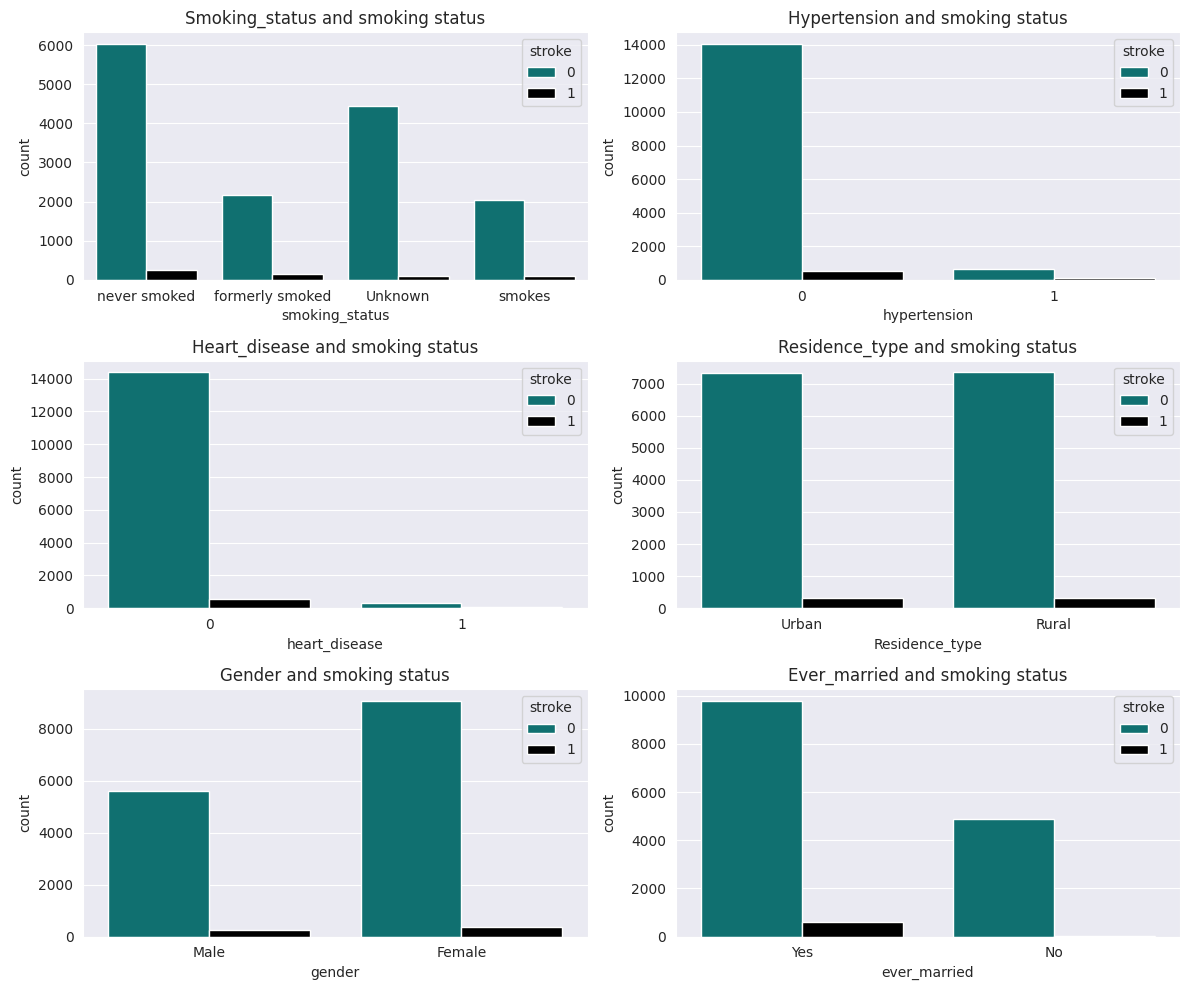

In [40]:
x_values = ['smoking_status', 'hypertension', 'heart_disease','Residence_type','gender', 'ever_married']
fig, axis = plt.subplots(nrows = 3, ncols = 2, figsize=(12, 10))

for ax, x_value in zip(axis.flat, x_values):
    sns.countplot(data = train_df, x = x_value, hue='stroke', ax = ax)
    ax.set_title(f'{x_value.capitalize()} and smoking status')

plt.tight_layout()
plt.show()

In [41]:
# Data Preparation & Preprocessing
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn import set_config

set_config(display = 'diagram')

In [42]:
train_df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [43]:
input_cols = list(train_df.columns)[1:-1]

In [44]:
target_col = 'stroke'

In [45]:
input_cols

['gender',
 'age',
 'hypertension',
 'heart_disease',
 'ever_married',
 'work_type',
 'Residence_type',
 'avg_glucose_level',
 'bmi',
 'smoking_status']

In [46]:
train_inputs = train_df[input_cols].copy()
train_target = train_df[target_col].copy()

test_inputs = test_df[input_cols].copy()

In [47]:
numerical_cols = train_inputs.select_dtypes(include=np.number).columns.to_list()

In [48]:
numerical_cols

['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

In [49]:
categorical_cols = train_inputs.select_dtypes(include='object').columns.to_list()

In [50]:
categorical_cols

['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

In [51]:
categorical_cols.remove('smoking_status')

In [52]:
train_df['smoking_status'].unique()

array(['never smoked', 'formerly smoked', 'Unknown', 'smokes'],
      dtype=object)

In [53]:
ordinal_enc = OrdinalEncoder(categories=[['Unknown','never smoked', 'formerly smoked','smokes']])

In [54]:
onehot_enc = OneHotEncoder(handle_unknown='ignore')

In [55]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
    ('Ordinal_Encode', ordinal_enc,['smoking_status']),
    ('OneHot_Encode', onehot_enc,categorical_cols)
]
)

In [56]:
preprocessor.fit(train_inputs)

ColumnTransformer(transformers=[('Ordinal_Encode',
                                 OrdinalEncoder(categories=[['Unknown',
                                                             'never smoked',
                                                             'formerly smoked',
                                                             'smokes']]),
                                 ['smoking_status']),
                                ('OneHot_Encode',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'ever_married', 'work_type',
                                  'Residence_type'])])

In [57]:
encoded_cols = list(preprocessor.get_feature_names_out())

In [58]:
encoded_cols

['Ordinal_Encode__smoking_status',
 'OneHot_Encode__gender_Female',
 'OneHot_Encode__gender_Male',
 'OneHot_Encode__ever_married_No',
 'OneHot_Encode__ever_married_Yes',
 'OneHot_Encode__work_type_Govt_job',
 'OneHot_Encode__work_type_Never_worked',
 'OneHot_Encode__work_type_Private',
 'OneHot_Encode__work_type_Self-employed',
 'OneHot_Encode__work_type_children',
 'OneHot_Encode__Residence_type_Rural',
 'OneHot_Encode__Residence_type_Urban']

In [59]:
train_inputs[encoded_cols] = preprocessor.transform(train_inputs)
test_inputs[encoded_cols] = preprocessor.transform(test_inputs)

In [60]:
X_train = train_inputs[numerical_cols + encoded_cols]
y_train = train_df[target_col]

X_test = test_inputs[numerical_cols + encoded_cols]

In [61]:
X_train.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,Ordinal_Encode__smoking_status,OneHot_Encode__gender_Female,OneHot_Encode__gender_Male,OneHot_Encode__ever_married_No,OneHot_Encode__ever_married_Yes,OneHot_Encode__work_type_Govt_job,OneHot_Encode__work_type_Never_worked,OneHot_Encode__work_type_Private,OneHot_Encode__work_type_Self-employed,OneHot_Encode__work_type_children,OneHot_Encode__Residence_type_Rural,OneHot_Encode__Residence_type_Urban
0,28.0,0,0,79.53,31.1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,33.0,0,0,78.44,23.9,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,42.0,0,0,103.00,40.3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,56.0,0,0,64.87,28.8,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,24.0,0,0,73.36,28.8,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [62]:
X_train.shape[1] == X_test.shape[1]

True

In [63]:
# Split Dataset into training and validation set
from sklearn.model_selection import train_test_split

In [64]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [65]:
X_train.shape

(12242, 17)

In [66]:
# Baseline Model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [67]:
models = [
    (LogisticRegression(), 'LogisticRegression'),
    (RandomForestClassifier(), 'RandomForestClassifier'),
    (XGBClassifier(), 'XGBClassifier'),
    (LGBMClassifier(verbose = 1), 'LightGBM')
]

In [68]:
def evalue_model(model, X_train, y_train, X_val, y_val):
    y_pred = model.predict(X_val)
    confusion_mat = confusion_matrix(y_val, y_pred)
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    return confusion_mat, accuracy, precision, recall, f1

In [69]:
confusion_mats = {}
def metric_df(model, model_name):
    confusion_mat, *df = evalue_model(model, X_train, y_train, X_val, y_val)
    confusion_mats[model_name] = confusion_mat
    df = [df]
    model_metrics = pd.DataFrame(data = df, columns=['Accuarcy','Precision', 'Recall', 'F1'])
    model_metrics.insert(0, 'Model', model_name)

    return model_metrics

In [70]:
predictions = []
for model, model_name in models:
    model.fit(X_train, y_train)
    model_metrics = metric_df(model, model_name)
    predictions.append(model_metrics)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



[LightGBM] [Info] Number of positive: 498, number of negative: 11744
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000920 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Number of data points in the train set: 12242, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.040680 -> initscore=-3.160498
[LightGBM] [Info] Start training from score -3.160498


In [71]:
predictions

[                Model  Accuarcy  Precision    Recall        F1
 0  LogisticRegression  0.955243   0.333333  0.022388  0.041958,
                     Model  Accuarcy  Precision    Recall        F1
 0  RandomForestClassifier  0.953283   0.285714  0.044776  0.077419,
            Model  Accuarcy  Precision    Recall        F1
 0  XGBClassifier  0.953283   0.363636  0.089552  0.143713,
       Model  Accuarcy  Precision    Recall        F1
 0  LightGBM   0.95459   0.380952  0.059701  0.103226]

In [72]:
oversample = SMOTE()
X_train_ns, y_train_ns = oversample.fit_resample(X_train, y_train)

In [73]:
X_train_ns.shape

(23488, 17)

In [74]:
lr_with_smote = LogisticRegression()
lr_with_smote.fit(X_train_ns, y_train_ns)
lr_with_smote_mat = metric_df(lr_with_smote, 'Logistic With SMOTE')
predictions.append(lr_with_smote_mat)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



In [75]:
for model_name , confusion_mat in confusion_mats.items():
    print(f'Confusion Matrix for {model_name}')
    print(confusion_mat)
    print()

Confusion Matrix for LogisticRegression
[[2921    6]
 [ 131    3]]

Confusion Matrix for RandomForestClassifier
[[2912   15]
 [ 128    6]]

Confusion Matrix for XGBClassifier
[[2906   21]
 [ 122   12]]

Confusion Matrix for LightGBM
[[2914   13]
 [ 126    8]]

Confusion Matrix for Logistic With SMOTE
[[2320  607]
 [  32  102]]



In [76]:
# Voting Classifer . Hard and Soft
from sklearn.ensemble import VotingClassifier

In [77]:
estimator = []
estimator.append(('LogisticRegression', LogisticRegression())),
estimator.append(('RandomForestClassifier', RandomForestClassifier())),
estimator.append(('XGBClassifier', XGBClassifier())),
estimator.append(('LightGBM', LGBMClassifier(verbose = 1)))

In [78]:
VC_hard = VotingClassifier(estimators=estimator, voting='hard')
VC_hard.fit(X_train, y_train)
VC_hard_mat = metric_df(VC_hard, 'VC_HARD')
predictions.append(VC_hard_mat)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



[LightGBM] [Info] Number of positive: 498, number of negative: 11744
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000751 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Number of data points in the train set: 12242, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.040680 -> initscore=-3.160498
[LightGBM] [Info] Start training from score -3.160498


In [79]:
VC_hard_mat

,Model,Accuarcy,Precision,Recall,F1
0,VC_HARD,0.955897,0.428571,0.022388,0.042553


In [80]:
VC_soft = VotingClassifier(estimators=estimator, voting='soft')
VC_soft.fit(X_train, y_train)
VC_soft_mat = metric_df(VC_soft, 'VC_soft')
predictions.append(VC_soft_mat)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



[LightGBM] [Info] Number of positive: 498, number of negative: 11744
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001177 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Number of data points in the train set: 12242, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.040680 -> initscore=-3.160498
[LightGBM] [Info] Start training from score -3.160498


In [81]:
VC_soft_mat

,Model,Accuarcy,Precision,Recall,F1
0,VC_soft,0.95557,0.428571,0.044776,0.081081


In [82]:
prediction_base = pd.concat(predictions, ignore_index=True, sort =False)
prediction_base = prediction_base.sort_values(by=['Recall'], ascending=False).style.hide(axis = 'index')

In [83]:
prediction_base

Model,Accuarcy,Precision,Recall,F1
Logistic With SMOTE,0.791245,0.143865,0.761194,0.241993
XGBClassifier,0.953283,0.363636,0.089552,0.143713
LightGBM,0.954590,0.380952,0.059701,0.103226
VC_soft,0.955570,0.428571,0.044776,0.081081
RandomForestClassifier,0.953283,0.285714,0.044776,0.077419
LogisticRegression,0.955243,0.333333,0.022388,0.041958
VC_HARD,0.955897,0.428571,0.022388,0.042553


In [84]:
models_to_plot = [
    'LogisticRegression',
    'RandomForestClassifier',
    'XGBClassifier',
    'Logistic With SMOTE'
]

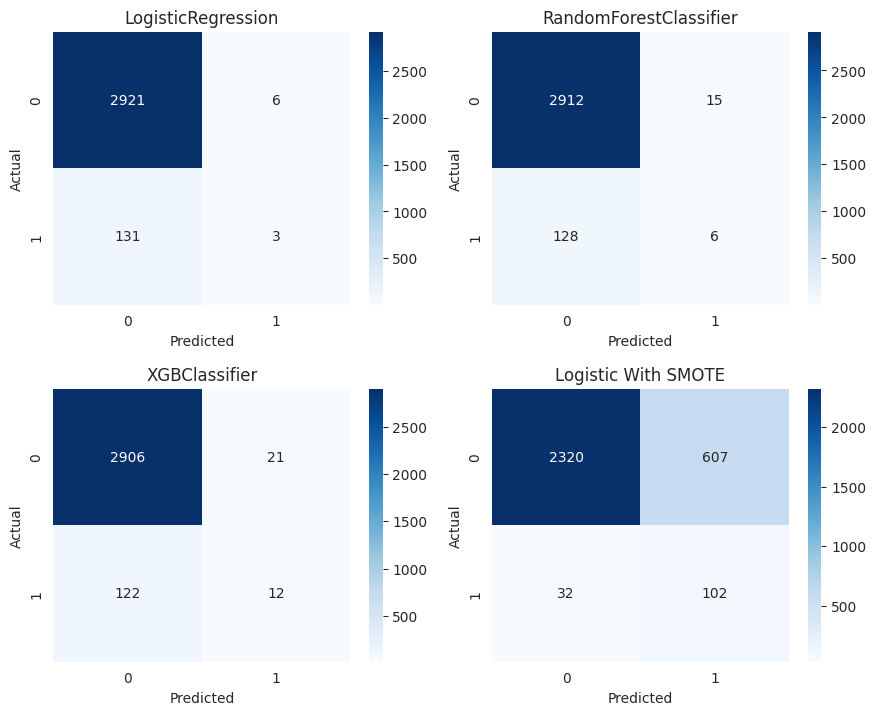

In [85]:
fig, axes = plt.subplots(nrows = 2, ncols =2, figsize = (9, 7))
for ax, model_name in zip(axes.ravel(), models_to_plot):
    confusion_mat = confusion_mats[model_name]
    sns.heatmap(confusion_mat, annot=True, fmt='d', cmap = 'Blues', ax = ax)
    ax.set_title(f'{model_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.subplots_adjust(left=0, right = 0.9, top =0.9, bottom = 0)
plt.show()

In [86]:
# AUC - ROC Curve Homework ->
from sklearn.metrics import roc_auc_score, roc_curve, auc
# Precision - recall curve
from sklearn.metrics import PredictionErrorDisplay

In [87]:
# Retrain & Save Model
X_train = train_inputs[numerical_cols + encoded_cols]
y_train = train_df[target_col]

In [88]:
preds = lr_with_smote.predict(X_test)

In [89]:
preds

array([0, 1, 0, ..., 0, 0, 0])

In [90]:
sub_df = preds

In [91]:
pd.DataFrame(sub_df).to_csv("submission.csv", index=None)

In [92]:
sub_df = pd.read_csv("submission.csv")

In [93]:
sub_df.head()

,0
0,0
1,1
2,0
3,1
4,0


In [94]:
# Make Prediction on a single input

sub_df['stroke'] = preds

In [95]:
sub_df

,0,stroke
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0
...,...,...
10198,0,0
10199,0,0
10200,0,0
10201,0,0


In [96]:
train_df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [97]:
single_input = {
    'gender': 'Male',
    'age': 33,
    'hypertension':0,
    'heart_disease': 0,
    'ever_married':'Yes',
    'work_type':'Private',
    'Residence_type':'Urban',
    'avg_glucose_level':79.53,
    'bmi': 31.10,
    'smoking_status': 'formerly smoked'
}

In [98]:
input_df = pd.DataFrame([single_input])

In [99]:
input_df[encoded_cols] = preprocessor.transform(input_df)

In [100]:
X = input_df[numerical_cols + encoded_cols]

In [101]:
lr_with_smote.predict(X)

array([0])

In [102]:
import joblib

In [103]:
model = {
    'encoded_cols': encoded_cols,
    'numeric_cols':numerical_cols,
    'preprocessor': preprocessor,
    'model': lr_with_smote
}

In [104]:
joblib.dump(model, 'model.joblib')

['model.joblib']

#Neural Network

In [108]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# =========================================================
# 1. Reproducibility
# =========================================================
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


# =========================================================
# 2. Load data
# =========================================================
train_df = pd.read_csv("https://raw.githubusercontent.com/Chando0185/Brain_Stroke_Prediction/main/train.csv")
test_df = pd.read_csv("https://raw.githubusercontent.com/Chando0185/Brain_Stroke_Prediction/main/test.csv")
sub_df = pd.read_csv("https://raw.githubusercontent.com/Chando0185/Brain_Stroke_Prediction/main/sample_submission.csv")


# =========================================================
# 3. Data cleaning to match the original code
# =========================================================
train_df["age"] = np.ceil(train_df["age"])
test_df["age"] = np.ceil(test_df["age"])

train_df = train_df[train_df["gender"] != "Other"].copy()
test_df = test_df[test_df["gender"] != "Other"].copy()


# =========================================================
# 4. Define input and target columns
#    Original code uses columns [1:-1] as inputs
# =========================================================
input_cols = list(train_df.columns)[1:-1]
target_col = "stroke"

train_inputs = train_df[input_cols].copy()
train_target = train_df[target_col].copy()
test_inputs = test_df[input_cols].copy()


# =========================================================
# 5. Identify numerical and categorical columns
# =========================================================
numerical_cols = train_inputs.select_dtypes(include=np.number).columns.to_list()
categorical_cols = train_inputs.select_dtypes(include="object").columns.to_list()

# Original code uses ordinal encoding for smoking_status
categorical_cols.remove("smoking_status")

ordinal_enc = OrdinalEncoder(
    categories=[["Unknown", "never smoked", "formerly smoked", "smokes"]]
)
onehot_enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("ordinal", ordinal_enc, ["smoking_status"]),
        ("onehot", onehot_enc, categorical_cols),
    ],
    remainder="drop"
)

preprocessor.fit(train_inputs)

encoded_cols = list(preprocessor.get_feature_names_out())

# Transform features
train_encoded = preprocessor.transform(train_inputs)
test_encoded = preprocessor.transform(test_inputs)

train_encoded_df = pd.DataFrame(
    train_encoded, columns=encoded_cols, index=train_inputs.index
)
test_encoded_df = pd.DataFrame(
    test_encoded, columns=encoded_cols, index=test_inputs.index
)

train_inputs_processed = pd.concat(
    [train_inputs[numerical_cols].reset_index(drop=True),
     train_encoded_df.reset_index(drop=True)],
    axis=1
)

test_inputs_processed = pd.concat(
    [test_inputs[numerical_cols].reset_index(drop=True),
     test_encoded_df.reset_index(drop=True)],
    axis=1
)

X = train_inputs_processed.values.astype(np.float32)
y = train_target.values.astype(np.float32)
X_test = test_inputs_processed.values.astype(np.float32)

print("Processed feature size:", X.shape[1])
print("Training samples:", X.shape[0])
print("Test samples:", X_test.shape[0])


# =========================================================
# 6. Train/validation split
# =========================================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)


# =========================================================
# 7. PyTorch Dataset
# =========================================================
class StrokeDataset(Dataset):
    def __init__(self, features, labels=None):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = None if labels is None else torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        if self.labels is None:
            return self.features[idx]
        return self.features[idx], self.labels[idx]


train_dataset = StrokeDataset(X_train, y_train)
val_dataset = StrokeDataset(X_val, y_val)
test_dataset = StrokeDataset(X_test, None)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)


# =========================================================
# 8. Define neural network
# =========================================================
class StrokeMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = StrokeMLP(input_dim=X_train.shape[1]).to(device)
print(model)


# =========================================================
# 9. Loss and optimizer
#    Since stroke data is usually imbalanced, use pos_weight
# =========================================================
num_pos = y_train.sum()
num_neg = len(y_train) - num_pos
pos_weight = torch.tensor([num_neg / max(num_pos, 1.0)], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)


# =========================================================
# 10. Training and evaluation functions
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0.0

    all_probs = []
    all_preds = []
    all_targets = []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).float()

        total_loss += loss.item() * xb.size(0)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    metrics = {
        "loss": avg_loss,
        "accuracy": accuracy_score(all_targets, all_preds),
        "precision": precision_score(all_targets, all_preds, zero_division=0),
        "recall": recall_score(all_targets, all_preds, zero_division=0),
        "f1": f1_score(all_targets, all_preds, zero_division=0),
        "confusion_matrix": confusion_matrix(all_targets, all_preds),
    }
    return metrics


# =========================================================
# 11. Train model
# =========================================================
num_epochs = 30
best_val_f1 = -1
best_model_path = "best_stroke_mlp.pt"

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(model, val_loader, criterion, device)

    print(
        f"Epoch [{epoch:02d}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Acc: {val_metrics['accuracy']:.4f} | "
        f"Prec: {val_metrics['precision']:.4f} | "
        f"Recall: {val_metrics['recall']:.4f} | "
        f"F1: {val_metrics['f1']:.4f}"
    )

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        torch.save(model.state_dict(), best_model_path)

print("\nBest validation F1:", best_val_f1)


# =========================================================
# 12. Load best model and final validation evaluation
# =========================================================
model.load_state_dict(torch.load(best_model_path, map_location=device))
final_val_metrics = evaluate(model, val_loader, criterion, device)

print("\nFinal Validation Metrics")
print("Accuracy :", final_val_metrics["accuracy"])
print("Precision:", final_val_metrics["precision"])
print("Recall   :", final_val_metrics["recall"])
print("F1 Score :", final_val_metrics["f1"])
print("Confusion Matrix:\n", final_val_metrics["confusion_matrix"])


# =========================================================
# 13. Predict on test set
# =========================================================
@torch.no_grad()
def predict(model, loader, device, threshold=0.5):
    model.eval()
    all_probs = []
    all_preds = []

    for xb in loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).long()

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    return np.array(all_probs), np.array(all_preds)

test_probs, test_preds = predict(model, test_loader, device)

print("\nTest predictions shape:", test_preds.shape)


# =========================================================
# 14. Save submission
#    If sample_submission.csv has a 'stroke' column, use it.
#    Otherwise save predictions only.
# =========================================================
submission = sub_df.copy()

# if "stroke" in submission.columns:
#     submission["stroke"] = test_preds
# else:
#     submission = pd.DataFrame({"stroke": test_preds})

submission = pd.DataFrame({
    "id": test_df["id"],   # if id exists
    "stroke": test_preds
})

submission.to_csv("submission_nn.csv", index=False)
print("Saved submission_nn.csv")


# =========================================================
# 15. Save full inference bundle
# =========================================================
artifact = {
    "model_state_dict_path": best_model_path,
    "input_dim": X_train.shape[1],
    "numerical_cols": numerical_cols,
    "encoded_cols": encoded_cols,
    "preprocessor": preprocessor,
    "threshold": 0.5,
}

joblib.dump(artifact, "stroke_nn_artifact.joblib")
print("Saved stroke_nn_artifact.joblib")


# =========================================================
# 16. Example: single patient inference
# =========================================================
single_input = {
    "gender": "Male",
    "age": 33,
    "hypertension": 0,
    "heart_disease": 0,
    "ever_married": "Yes",
    "work_type": "Private",
    "Residence_type": "Urban",
    "avg_glucose_level": 79.53,
    "bmi": 31.10,
    "smoking_status": "formerly smoked"
}

single_df = pd.DataFrame([single_input])

single_df["age"] = np.ceil(single_df["age"])

single_encoded = preprocessor.transform(single_df)
single_encoded_df = pd.DataFrame(single_encoded, columns=encoded_cols)

single_processed = pd.concat(
    [single_df[numerical_cols].reset_index(drop=True),
     single_encoded_df.reset_index(drop=True)],
    axis=1
)

single_x = torch.tensor(single_processed.values.astype(np.float32)).to(device)

model.eval()
with torch.no_grad():
    single_logit = model(single_x)
    single_prob = torch.sigmoid(single_logit).item()
    single_pred = int(single_prob >= 0.5)

print("\nSingle patient probability:", single_prob)
print("Single patient predicted class:", single_pred)

Processed feature size: 17
Training samples: 15303
Test samples: 10203
Train shape: (12242, 17)
Validation shape: (3061, 17)
StrokeMLP(
  (net): Sequential(
    (0): Linear(in_features=17, out_features=64, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
  )
)
Epoch [01/30] Train Loss: 1.0200 | Val Loss: 0.7966 | Acc: 0.7076 | Prec: 0.1136 | Recall: 0.8968 | F1: 0.2016
Epoch [02/30] Train Loss: 0.8744 | Val Loss: 0.7660 | Acc: 0.7426 | Prec: 0.1221 | Recall: 0.8492 | F1: 0.2136
Epoch [03/30] Train Loss: 0.8540 | Val Loss: 0.7556 | Acc: 0.7406 | Pre

#Apply LIME

In [109]:
!pip install -q interpret lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 62.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 19.0 MB/s eta 0:00:00



LIME explanation for validation sample 0
True label: 0
Predicted class: No Stroke
Predicted probabilities: [0.9489042  0.05109576]


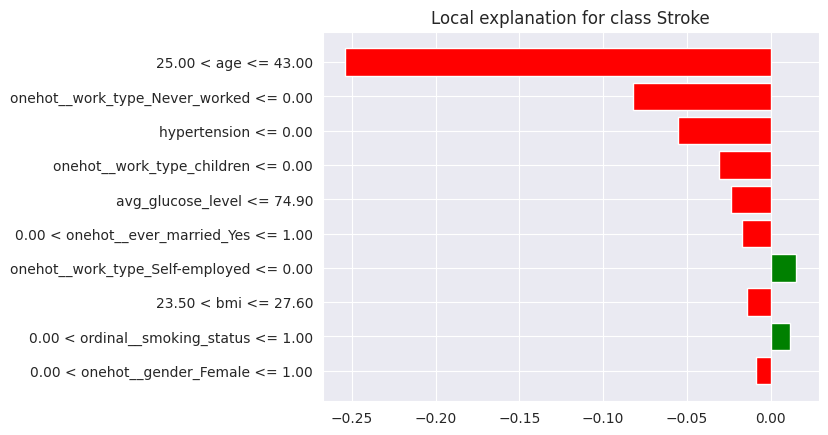

Saved lime_explanation_val_sample.html

LIME explanation for single patient
Predicted class: No Stroke
Predicted probabilities: [0.9134796  0.08652037]


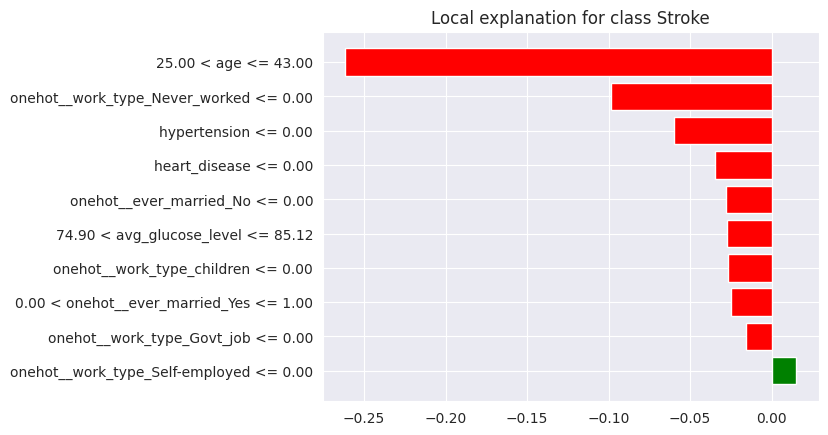

Saved lime_explanation_single_patient.html


In [114]:
# =========================================================
# 17. LIME explanation for the neural network
# =========================================================
# pip install -q lime

from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt

# Feature names in the exact order used by the neural network
feature_names = train_inputs_processed.columns.tolist()
class_names = ["No Stroke", "Stroke"]

# LIME needs a prediction function that takes numpy array input
# and returns probabilities for both classes: [P(No Stroke), P(Stroke)]
def lime_predict_fn(x):
    x_tensor = torch.tensor(x.astype(np.float32), dtype=torch.float32).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(x_tensor)
        probs_pos = torch.sigmoid(logits).cpu().numpy().reshape(-1, 1)
        probs_neg = 1.0 - probs_pos
        probs = np.hstack([probs_neg, probs_pos])
    return probs

# Build explainer on processed training data
explainer = LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True
)

# ---------------------------------------------------------
# Explain one validation sample
# ---------------------------------------------------------
sample_idx = 0

exp = explainer.explain_instance(
    data_row=X_val[sample_idx],
    predict_fn=lime_predict_fn,
    num_features=10
)

# Print prediction info
sample_probs = lime_predict_fn(X_val[sample_idx].reshape(1, -1))[0]
sample_pred = np.argmax(sample_probs)

print("\nLIME explanation for validation sample", sample_idx)
print("True label:", int(y_val[sample_idx]))
print("Predicted class:", class_names[sample_pred])
print("Predicted probabilities:", sample_probs)

# Show explanation in notebook
exp.show_in_notebook(show_table=True)

# Optional: plot explanation
fig = exp.as_pyplot_figure()
plt.show()

# Optional: save explanation
exp.save_to_file("lime_explanation_val_sample.html")
print("Saved lime_explanation_val_sample.html")


# ---------------------------------------------------------
# Explain the single patient example from section 16
# ---------------------------------------------------------
single_np = single_processed.values.astype(np.float32)

single_exp = explainer.explain_instance(
    data_row=single_np[0],
    predict_fn=lime_predict_fn,
    num_features=10
)

single_probs = lime_predict_fn(single_np)[0]
single_pred_class = np.argmax(single_probs)

print("\nLIME explanation for single patient")
print("Predicted class:", class_names[single_pred_class])
print("Predicted probabilities:", single_probs)

single_exp.show_in_notebook(show_table=True)

fig = single_exp.as_pyplot_figure()
plt.show()

single_exp.save_to_file("lime_explanation_single_patient.html")
print("Saved lime_explanation_single_patient.html")